In [1]:
import pandas as pd
#  All numerical (classical)
df_all = pd.read_csv("MRI_All_Numerical_Features.xls")
# Quantum features (QFT + QWT patches)
df_quantum = pd.read_csv("MRI_Quantum_QFT_QWT_Patch_Features.xls")
# Classical + Quantum fused features
df_fused = pd.read_csv("MRI_Classical_Quantum_Fused_Features.xls")
# Print shapes
print("All Numerical Shape:", df_all.shape)
print("Quantum Features Shape:", df_quantum.shape)
print("Fused Features Shape:", df_fused.shape)


All Numerical Shape: (8763, 101)
Quantum Features Shape: (8763, 33)
Fused Features Shape: (8763, 133)


In [6]:
datasets = [df_all, df_quantum, df_fused]
names = ["All Numerical", "Quantum Features", "Fused Features"]
for df, name in zip(datasets, names):
    print(f"\n{name} Label Counts:")
    if 'label' in df.columns:
        print(df['label'].value_counts())
    else:
        print("Warning: 'label' column not found!")


All Numerical Label Counts:
label
0    6621
1    2142
Name: count, dtype: int64

Quantum Features Label Counts:
label
0    6621
1    2142
Name: count, dtype: int64

Fused Features Label Counts:
label
0    6621
1    2142
Name: count, dtype: int64


In [8]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][imbalanced-learn]


In [9]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler

# Load datasets
df_all = pd.read_csv("MRI_All_Numerical_Features.xls")
df_quantum = pd.read_csv("MRI_Quantum_QFT_QWT_Patch_Features.xls")
df_fused = pd.read_csv("MRI_Classical_Quantum_Fused_Features.xls")

datasets = [df_all, df_quantum, df_fused]
names = ["All Numerical", "Quantum Features", "Fused Features"]

balanced_dfs = []

# Oversample each dataset
ros = RandomOverSampler(random_state=42)

for df, name in zip(datasets, names):
    print(f"\n{name} Before Oversampling:")
    print(df['label'].value_counts())
    
    # Split features and label
    X = df.drop('label', axis=1)
    y = df['label']
    
    # Apply RandomOverSampler
    X_res, y_res = ros.fit_resample(X, y)
    
    # Combine back into DataFrame
    df_balanced = pd.DataFrame(X_res, columns=X.columns)
    df_balanced['label'] = y_res
    balanced_dfs.append(df_balanced)
    
    print(f"{name} After Oversampling:")
    print(df_balanced['label'].value_counts())



All Numerical Before Oversampling:
label
0    6621
1    2142
Name: count, dtype: int64
All Numerical After Oversampling:
label
1    6621
0    6621
Name: count, dtype: int64

Quantum Features Before Oversampling:
label
0    6621
1    2142
Name: count, dtype: int64
Quantum Features After Oversampling:
label
1    6621
0    6621
Name: count, dtype: int64

Fused Features Before Oversampling:
label
0    6621
1    2142
Name: count, dtype: int64
Fused Features After Oversampling:
label
1    6621
0    6621
Name: count, dtype: int64


In [10]:
# Shuffle the balanced datasets
for i in range(len(balanced_dfs)):
    balanced_dfs[i] = balanced_dfs[i].sample(frac=1, random_state=42).reset_index(drop=True)
# Save to CSV
balanced_dfs[0].to_csv("C.csv", index=False)   # All Numerical
balanced_dfs[1].to_csv("Q.csv", index=False)   # Quantum Features
balanced_dfs[2].to_csv("QC.csv", index=False)  # Fused Features
print("Balanced datasets shuffled and saved successfully as C.csv, Q.csv, and QC.csv")


Balanced datasets shuffled and saved successfully as C.csv, Q.csv, and QC.csv


In [11]:
import pandas as pd
# Load the saved CSV files
df_C = pd.read_csv("C.csv")
df_Q = pd.read_csv("Q.csv")
df_QC = pd.read_csv("QC.csv")
# Print label counts
datasets = [df_C, df_Q, df_QC]
names = ["All Numerical (C.csv)", "Quantum Features (Q.csv)", "Fused Features (QC.csv)"]
for df, name in zip(datasets, names):
    print(f"\n{name} Label Counts:")
    print(df['label'].value_counts())



All Numerical (C.csv) Label Counts:
label
1    6621
0    6621
Name: count, dtype: int64

Quantum Features (Q.csv) Label Counts:
label
1    6621
0    6621
Name: count, dtype: int64

Fused Features (QC.csv) Label Counts:
label
1    6621
0    6621
Name: count, dtype: int64


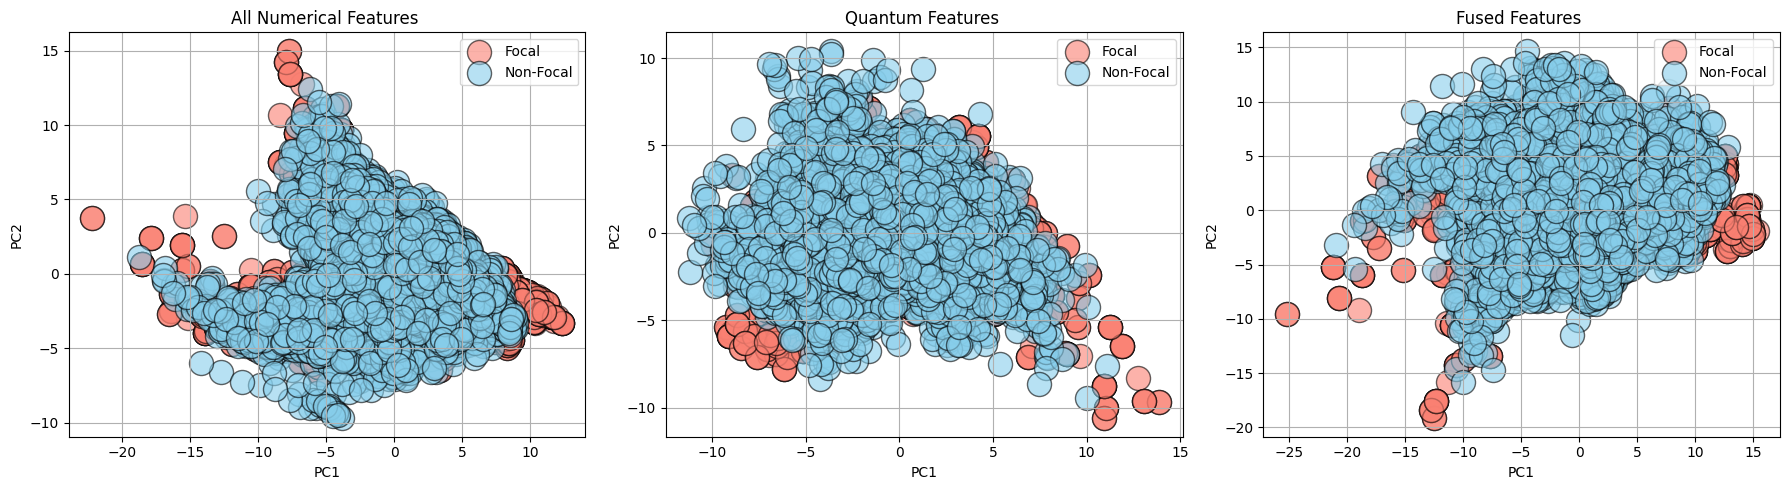

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

datasets = {
    "All Numerical Features ": "C.csv",
    "Quantum Features ": "Q.csv",
    "Fused Features ": "QC.csv"
}

colors = {0:'skyblue', 1:'salmon'}
labels_dict = {0:'Non-Focal', 1:'Focal'}

plt.figure(figsize=(18,5))

for i, (name, path) in enumerate(datasets.items(), 1):
    df = pd.read_csv(path)
    X = df.drop('label', axis=1)
    y = df['label']
    
    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)
    
    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
    df_pca['label'] = y
    
    # Plot
    plt.subplot(1, 3, i)
    for label in df_pca['label'].unique():
        subset = df_pca[df_pca['label'] == label]
        plt.scatter(subset['PC1'], subset['PC2'], 
                    c=colors[label], label=labels_dict[label],
                    alpha=0.6, edgecolors='k', s=300)
    
    plt.title(name)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


In [16]:
# Shuffle the balanced datasets
for i in range(len(balanced_dfs)):
    balanced_dfs[i] = balanced_dfs[i].sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
balanced_dfs[0].to_csv("C.csv", index=False)   # All Numerical
balanced_dfs[1].to_csv("Q.csv", index=False)   # Quantum Features
balanced_dfs[2].to_csv("QC.csv", index=False)  # Fused Features

print("Balanced datasets shuffled and saved successfully as C.csv, Q.csv, and QC.csv")

# Print 5 samples from each dataset
print("\n5 samples from C.csv (All Numerical):")
print(balanced_dfs[0].head(5))

print("\n5 samples from Q.csv (Quantum Features):")
print(balanced_dfs[1].head(5))

print("\n5 samples from QC.csv (Fused Features):")
print(balanced_dfs[2].head(5))


Balanced datasets shuffled and saved successfully as C.csv, Q.csv, and QC.csv

5 samples from C.csv (All Numerical):
           F0     F1         F2           F3  F4   F5   F6         F7  \
0   44.506776    1.0  67.408705  4543.933508   0  255  255   7.072215   
1   61.024235   21.0  67.619900  4572.450824   0  255  255  10.624139   
2   81.655632   73.0  64.403348  4147.791228   0  255  255   9.869548   
3  100.092873  107.0  63.376824  4016.621835   0  255  255  10.164513   
4   77.406649   64.0  68.721140  4722.595120   0  254  254  10.321450   

         F8        F9  ...      F91          F92       F93       F94  \
0  1.395886  0.482056  ...  11394.0  2321.911001  0.187398  0.568620   
1  1.306030  0.595065  ...  15180.0  2423.776008  0.660354  0.755976   
2  0.363035 -1.136068  ...  23028.0  4288.116375  0.436771  0.610822   
3  0.012196 -1.193613  ...  30174.0  4631.283943  0.412686  0.659152   
4  0.682343 -0.619967  ...  21499.0  4255.736649  0.611288  0.635388   

        F95

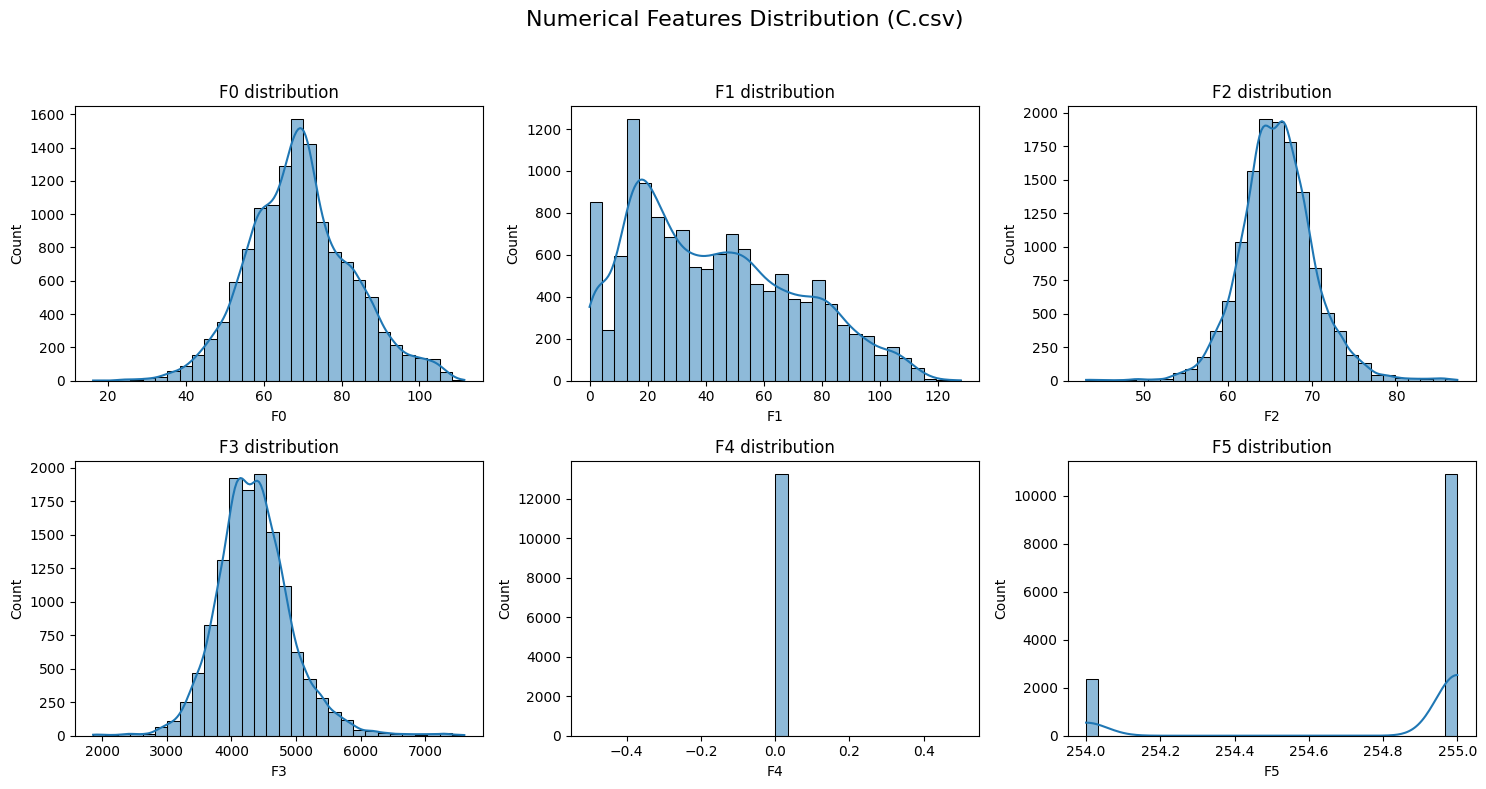

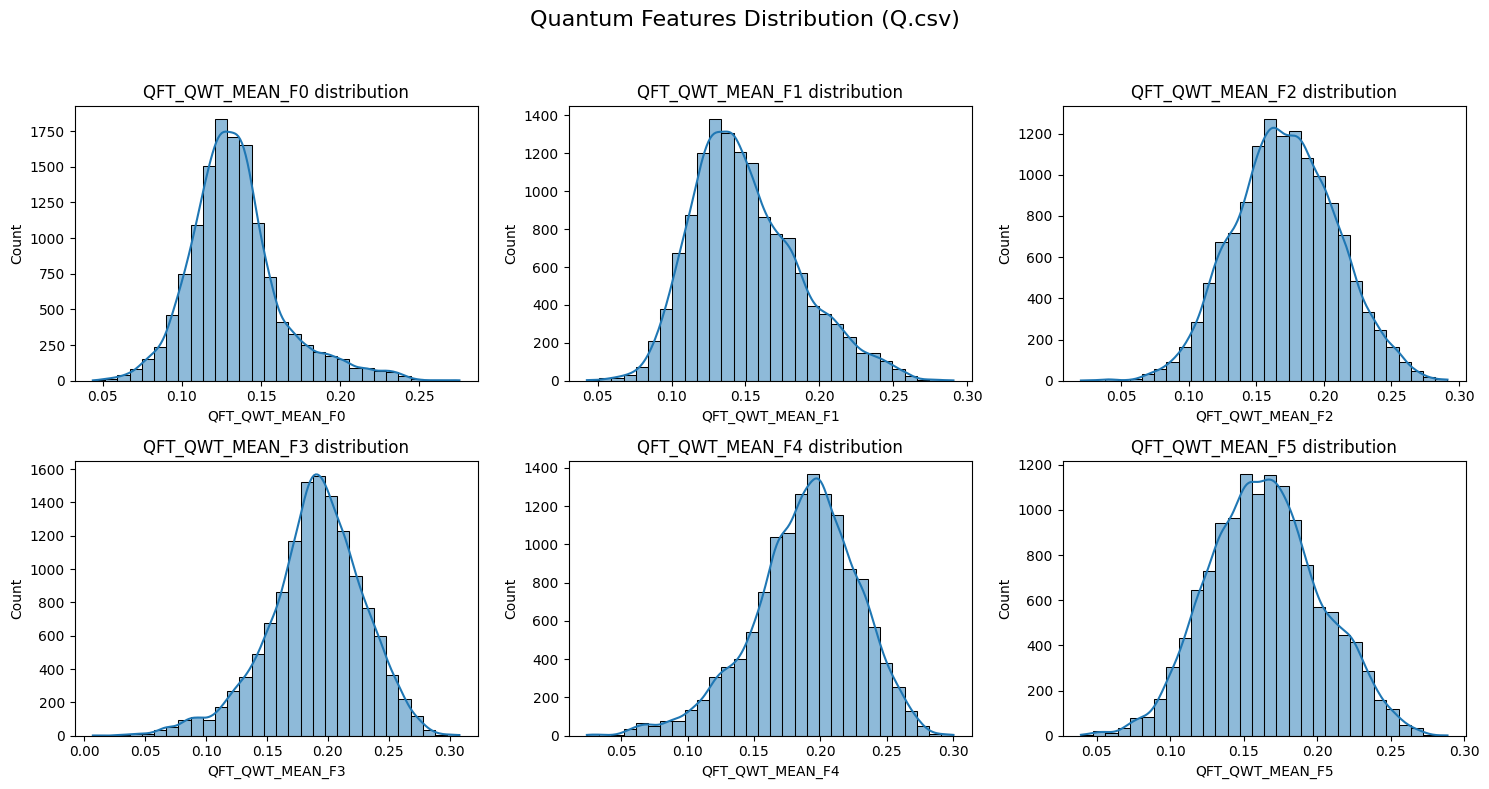

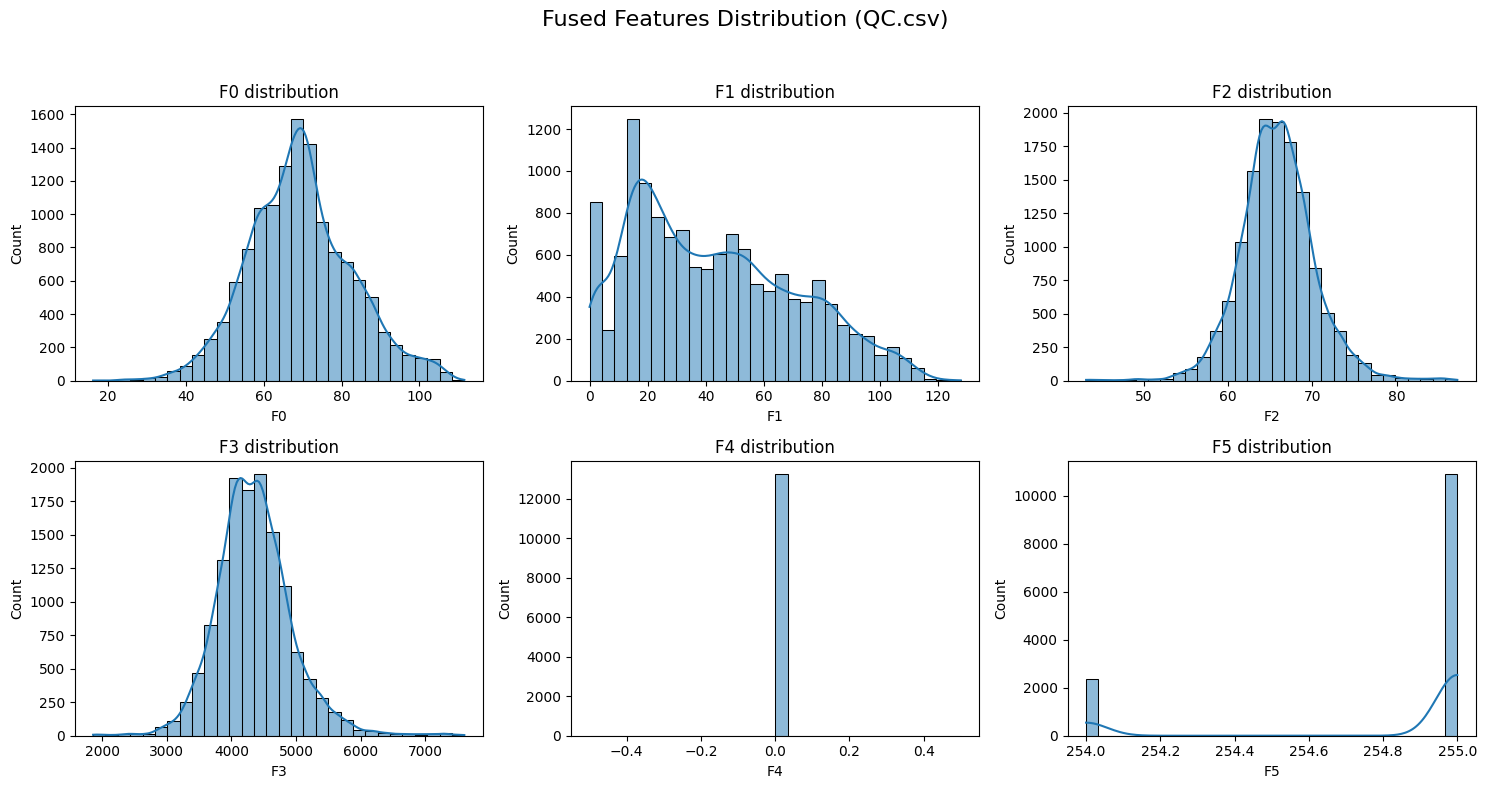

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load datasets (if not already in memory)
C_df = pd.read_csv("C.csv")
Q_df = pd.read_csv("Q.csv")
QC_df = pd.read_csv("QC.csv")

# Function to plot distributions for selected features
def plot_distributions(df, title, features, n_cols=3):
    n_rows = (len(features) + n_cols - 1) // n_cols
    plt.figure(figsize=(5*n_cols, 4*n_rows))
    
    for i, feat in enumerate(features):
        plt.subplot(n_rows, n_cols, i+1)
        sns.histplot(df[feat], kde=True, bins=30)
        plt.title(f"{feat} distribution")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example: pick first 6 numerical features from C_df
numerical_features = C_df.columns[:6].tolist()
plot_distributions(C_df, "Numerical Features Distribution (C.csv)", numerical_features)

# Example: pick first 6 quantum features from Q_df (excluding label)
quantum_features = Q_df.columns[:6].tolist()
plot_distributions(Q_df, "Quantum Features Distribution (Q.csv)", quantum_features)

# Example: pick first 6 fused features from QC_df (excluding label)
fused_features = QC_df.columns[:6].tolist()
plot_distributions(QC_df, "Fused Features Distribution (QC.csv)", fused_features)


In [19]:
def find_duplicate_columns(df):
    duplicates = []
    cols = df.columns
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if df[cols[i]].equals(df[cols[j]]):
                duplicates.append((cols[i], cols[j]))
    return duplicates

print("Duplicate features in C.csv:", find_duplicate_columns(C_df))
print("Duplicate features in Q.csv:", find_duplicate_columns(Q_df))
print("Duplicate features in QC.csv:", find_duplicate_columns(QC_df))


Duplicate features in C.csv: [('F1', 'F14'), ('F5', 'F6'), ('F38', 'F39'), ('F38', 'F40'), ('F38', 'F41'), ('F38', 'F42'), ('F38', 'F43'), ('F38', 'F44'), ('F38', 'F45'), ('F38', 'F46'), ('F38', 'F47'), ('F38', 'F48'), ('F38', 'F49'), ('F38', 'F50'), ('F38', 'F51'), ('F38', 'F52'), ('F38', 'F53'), ('F38', 'F54'), ('F38', 'F55'), ('F38', 'F56'), ('F38', 'F57'), ('F38', 'F58'), ('F38', 'F59'), ('F38', 'F60'), ('F38', 'F61'), ('F38', 'F62'), ('F38', 'F63'), ('F38', 'F64'), ('F38', 'F65'), ('F38', 'F66'), ('F38', 'F67'), ('F38', 'F68'), ('F38', 'F69'), ('F38', 'F70'), ('F38', 'F71'), ('F38', 'F72'), ('F38', 'F73'), ('F38', 'F74'), ('F38', 'F75'), ('F38', 'F76'), ('F38', 'F77'), ('F38', 'F78'), ('F38', 'F79'), ('F38', 'F80'), ('F38', 'F81'), ('F38', 'F82'), ('F38', 'F83'), ('F38', 'F84'), ('F38', 'F85'), ('F38', 'F86'), ('F39', 'F40'), ('F39', 'F41'), ('F39', 'F42'), ('F39', 'F43'), ('F39', 'F44'), ('F39', 'F45'), ('F39', 'F46'), ('F39', 'F47'), ('F39', 'F48'), ('F39', 'F49'), ('F39', 'F50'

In [20]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
def remove_duplicate_columns(df):
    df_no_label = df.drop(columns=["label"])
    df_unique = df_no_label.loc[:, ~df_no_label.T.duplicated()]
    return pd.concat([df_unique, df["label"]], axis=1)


In [21]:
def remove_low_variance(df, threshold=1e-5):
    features = df.drop(columns=["label"])
    selector = VarianceThreshold(threshold=threshold)
    reduced = selector.fit_transform(features)
    kept_columns = features.columns[selector.get_support()]
    
    return pd.concat(
        [pd.DataFrame(reduced, columns=kept_columns), df["label"].reset_index(drop=True)],
        axis=1
    )


In [22]:
def remove_high_correlation(df, threshold=0.98):
    features = df.drop(columns=["label"])
    corr = features.corr().abs()
    
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    cleaned = features.drop(columns=to_drop)
    return pd.concat([cleaned, df["label"]], axis=1)


In [23]:
def auto_clean_dataset(df, name):
    print(f"\n🔹 Cleaning {name}")
    print("Original shape:", df.shape)
    
    df = remove_duplicate_columns(df)
    print("After duplicate removal:", df.shape)
    
    df = remove_low_variance(df)
    print("After low-variance removal:", df.shape)
    
    df = remove_high_correlation(df)
    print("After correlation pruning:", df.shape)
    
    return df


In [24]:
C_df = pd.read_csv("C.csv")
Q_df = pd.read_csv("Q.csv")
QC_df = pd.read_csv("QC.csv")

C_clean = auto_clean_dataset(C_df, "C.csv")
Q_clean = auto_clean_dataset(Q_df, "Q.csv")
QC_clean = auto_clean_dataset(QC_df, "QC.csv")



🔹 Cleaning C.csv
Original shape: (13242, 101)
After duplicate removal: (13242, 50)
After low-variance removal: (13242, 49)
After correlation pruning: (13242, 44)

🔹 Cleaning Q.csv
Original shape: (13242, 33)
After duplicate removal: (13242, 33)
After low-variance removal: (13242, 31)
After correlation pruning: (13242, 31)

🔹 Cleaning QC.csv
Original shape: (13242, 133)
After duplicate removal: (13242, 82)
After low-variance removal: (13242, 79)
After correlation pruning: (13242, 74)


In [25]:
C_clean.to_csv("C_clean.csv", index=False)
Q_clean.to_csv("Q_clean.csv", index=False)
QC_clean.to_csv("QC_clean.csv", index=False)
print("\nCleaned datasets saved as:")
print("C_clean.csv, Q_clean.csv, QC_clean.csv")



Cleaned datasets saved as:
C_clean.csv, Q_clean.csv, QC_clean.csv


In [26]:
import pandas as pd
C_clean = pd.read_csv("C_clean.csv")
Q_clean = pd.read_csv("Q_clean.csv")
QC_clean = pd.read_csv("QC_clean.csv")
print("C_clean shape:", C_clean.shape)
print("Q_clean shape:", Q_clean.shape)
print("QC_clean shape:", QC_clean.shape)


C_clean shape: (13242, 44)
Q_clean shape: (13242, 31)
QC_clean shape: (13242, 74)


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
def plot_pca(df, title):
    X = df.drop(columns=["label"])
    y = df["label"]

    # Standardize features (VERY important for PCA)
    X_scaled = StandardScaler().fit_transform(X)

    # PCA to 2 components
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Plot
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y,
        alpha=0.6
    )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
    plt.title(title)
    plt.colorbar(scatter, label="Class Label")
    plt.grid(True)
    plt.show()


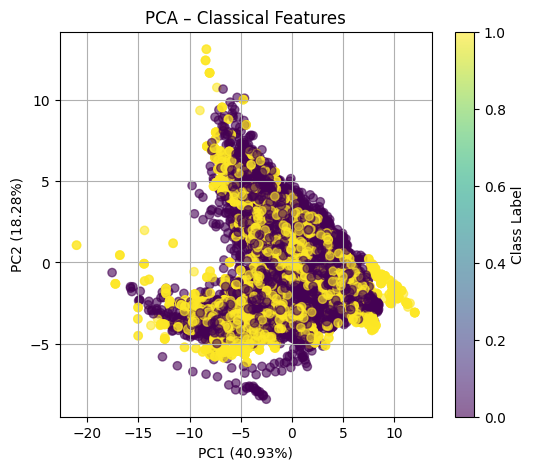

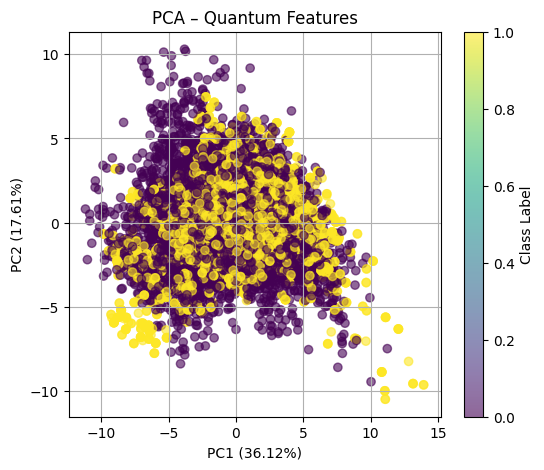

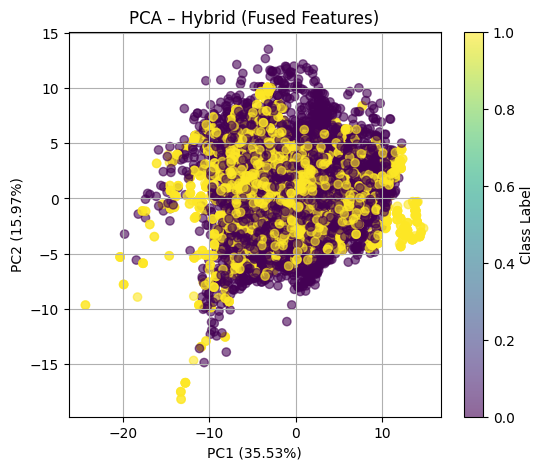

In [32]:
plot_pca(C_clean, "PCA – Classical Features")
plot_pca(Q_clean, "PCA – Quantum Features")
plot_pca(QC_clean, "PCA – Hybrid (Fused Features)")


In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
def plot_explained_variance(df, title):
    X = df.drop(columns=["label"])

    # Standardize
    X_scaled = StandardScaler().fit_transform(X)

    # Full PCA
    pca = PCA()
    pca.fit(X_scaled)

    explained_var = np.cumsum(pca.explained_variance_ratio_)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(
        range(1, len(explained_var) + 1),
        explained_var,
        marker='o'
    )
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title(title)
    plt.grid(True)
    plt.ylim(0, 1.05)
    plt.show()


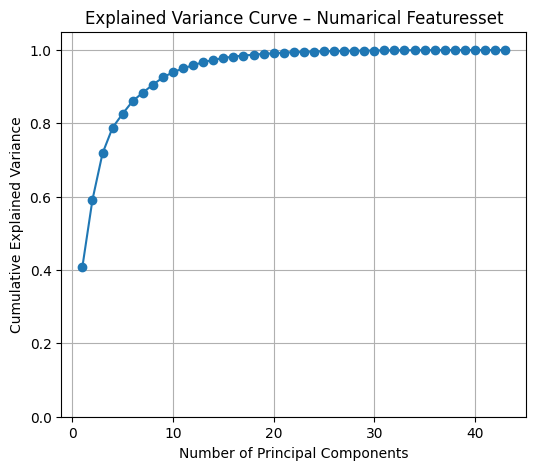

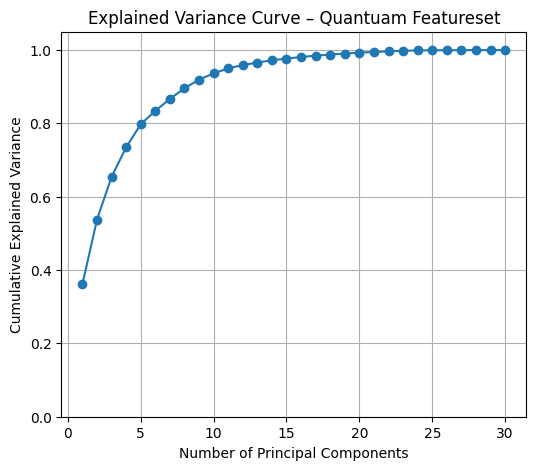

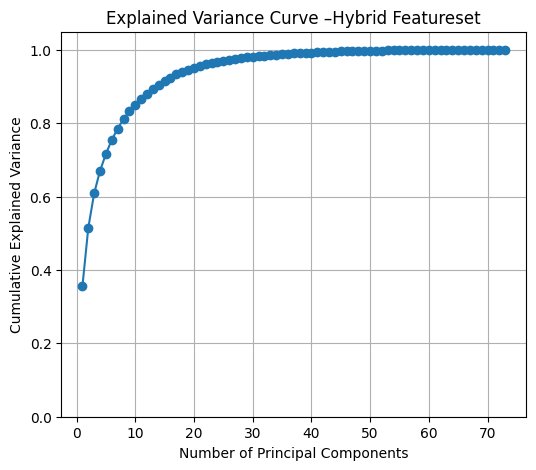

In [31]:
plot_explained_variance(C_clean, "Explained Variance Curve – Numarical Featuresset")
plot_explained_variance(Q_clean, "Explained Variance Curve – Quantuam Featureset")
plot_explained_variance(QC_clean, "Explained Variance Curve –Hybrid Featureset")


In [33]:
print("Label count in C_clean:")
print(C_clean["label"].value_counts())

print("\nLabel count in Q_clean:")
print(Q_clean["label"].value_counts())

print("\nLabel count in QC_clean:")
print(QC_clean["label"].value_counts())


Label count in C_clean:
label
1    6621
0    6621
Name: count, dtype: int64

Label count in Q_clean:
label
1    6621
0    6621
Name: count, dtype: int64

Label count in QC_clean:
label
1    6621
0    6621
Name: count, dtype: int64


In [34]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)


In [35]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "Train_Time_sec": train_time,
        "CM": confusion_matrix(y_test, y_pred),
        "ROC": roc_curve(y_test, y_prob) if y_prob is not None else None
    }
    
    return metrics


In [36]:
datasets = {
    "C": C_clean,
    "Q": Q_clean,
    "QC": QC_clean
}

models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True))
    ]),
    "RF": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42
    )
}


In [37]:
results = {}

for dname, df in datasets.items():
    X = df.drop(columns=["label"])
    y = df["label"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    for mname, model in models.items():
        key = f"{mname}_{dname}"
        results[key] = train_and_evaluate(
            model, X_train, X_test, y_train, y_test
        )


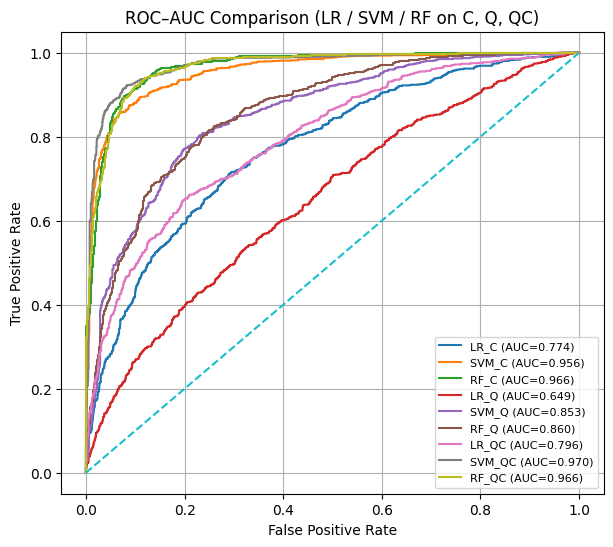

In [38]:
plt.figure(figsize=(7, 6))
for key, res in results.items():
    if res["ROC"] is not None:
        fpr, tpr, _ = res["ROC"]
        plt.plot(fpr, tpr, label=f"{key} (AUC={res['AUC']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Comparison (LR / SVM / RF on C, Q, QC)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


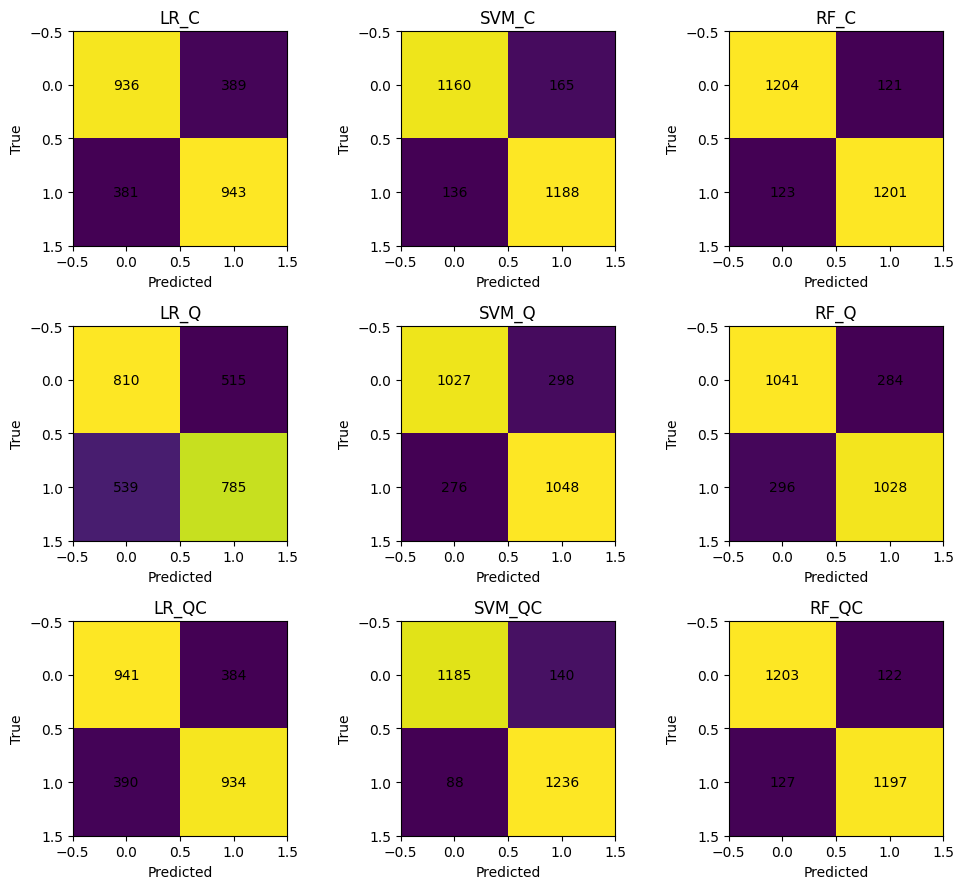

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(10, 9))
axes = axes.flatten()
for ax, (key, res) in zip(axes, results.items()):
    cm = res["CM"]
    ax.imshow(cm)
    ax.set_title(key)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


In [40]:
summary = []

for key, res in results.items():
    summary.append([
        key,
        res["Accuracy"],
        res["Precision"],
        res["Recall"],
        res["F1"],
        res["AUC"],
        res["Train_Time_sec"]
    ])

summary_df = pd.DataFrame(
    summary,
    columns=["Model", "Acc", "Prec", "Recall", "F1", "AUC", "Train_Time(s)"]
)

print(summary_df.sort_values("AUC", ascending=False))


    Model       Acc      Prec    Recall        F1       AUC  Train_Time(s)
7  SVM_QC  0.913930  0.898256  0.933535  0.915556  0.969919      86.661219
2    RF_C  0.907890  0.908472  0.907100  0.907785  0.965828       3.318167
8   RF_QC  0.906002  0.907506  0.904079  0.905789  0.965541       5.951372
1   SVM_C  0.886372  0.878049  0.897281  0.887561  0.955977      49.965312
5    RF_Q  0.781049  0.783537  0.776435  0.779970  0.860155       3.652068
4   SVM_Q  0.783314  0.778603  0.791541  0.785019  0.852794      53.875636
6   LR_QC  0.707814  0.708649  0.705438  0.707040  0.796144       3.146441
0    LR_C  0.709324  0.707958  0.712236  0.710090  0.773848       0.331110
3    LR_Q  0.602114  0.603846  0.592900  0.598323  0.648876       0.131177


In [42]:
# ------------------------ QFFMLNet class ------------------------
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

class QFFMLNet:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.smote = SMOTE(random_state=self.random_state)

        self.rf = RandomForestClassifier(random_state=self.random_state)
        self.gb = GradientBoostingClassifier(random_state=self.random_state)
        self.lr = LogisticRegression(max_iter=1000, random_state=self.random_state)
        self.svc = SVC(probability=True, random_state=self.random_state)

        self.best_rf = None
        self.best_gb = None
        self.best_lr = None
        self.best_svc = None
        self.ensemble = None

    def create_pipeline(self, clf):
        return ImbPipeline([
            ('smote', self.smote),
            ('scaler', self.scaler),
            ('clf', clf)
        ])

    def tune_models(self, X_train, y_train):
        param_grid_rf = {
            'clf__n_estimators': [100, 300, 500],
            'clf__max_depth': [None, 10, 20],
            'clf__min_samples_split': [2, 5, 10],
        }
        param_grid_gb = {
            'clf__n_estimators': [100, 200],
            'clf__learning_rate': [0.05, 0.1, 0.2],
            'clf__max_depth': [3, 5, 7],
        }
        param_grid_lr = {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2'],
            'clf__solver': ['lbfgs'],
        }
        param_grid_svc = {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto'],
            'clf__kernel': ['rbf', 'linear'],
        }

        pipe_rf = self.create_pipeline(self.rf)
        pipe_gb = self.create_pipeline(self.gb)
        pipe_lr = self.create_pipeline(self.lr)
        pipe_svc = self.create_pipeline(self.svc)

        rs_rf = RandomizedSearchCV(pipe_rf, param_grid_rf, n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)
        rs_gb = RandomizedSearchCV(pipe_gb, param_grid_gb, n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)
        rs_lr = RandomizedSearchCV(pipe_lr, param_grid_lr, n_iter=8, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)
        rs_svc = RandomizedSearchCV(pipe_svc, param_grid_svc, n_iter=8, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)

        print("Tuning Random Forest...")
        rs_rf.fit(X_train, y_train)
        self.best_rf = rs_rf.best_estimator_

        print("Tuning Gradient Boosting...")
        rs_gb.fit(X_train, y_train)
        self.best_gb = rs_gb.best_estimator_

        print("Tuning Logistic Regression...")
        rs_lr.fit(X_train, y_train)
        self.best_lr = rs_lr.best_estimator_

        print("Tuning SVC...")
        rs_svc.fit(X_train, y_train)
        self.best_svc = rs_svc.best_estimator_

    def train_ensemble(self, X_train, y_train):
        clf_rf = self.best_rf.named_steps['clf']
        clf_gb = self.best_gb.named_steps['clf']
        clf_lr = self.best_lr.named_steps['clf']
        clf_svc = self.best_svc.named_steps['clf']

        self.ensemble = VotingClassifier(
            estimators=[
                ('rf', clf_rf),
                ('gb', clf_gb),
                ('lr', clf_lr),
                ('svc', clf_svc)
            ],
            voting='soft',
            n_jobs=-1
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_train_res, y_train_res = self.smote.fit_resample(X_train_scaled, y_train)
        self.ensemble.fit(X_train_res, y_train_res)

    def evaluate(self, X_test, y_test):
        X_test_scaled = self.scaler.transform(X_test)
        y_pred = self.ensemble.predict(X_test_scaled)
        y_proba = self.ensemble.predict_proba(X_test_scaled)[:, 1]

        print("QFF-ML Net")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("QFF-ML Net Confusion Matrix")
        plt.show()

        auc_score = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)

        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"QFF-ML Net (AUC = {auc_score:.3f})")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("QFF-ML Net ROC Curve")
        plt.legend()
        plt.grid(alpha=0.5)
        plt.show()



==================== Dataset: C ====================
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning Logistic Regression...
Tuning SVC...
QFF-ML Net
Accuracy: 0.9852774631936579
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1325
           1       0.98      0.99      0.99      1324

    accuracy                           0.99      2649
   macro avg       0.99      0.99      0.99      2649
weighted avg       0.99      0.99      0.99      2649



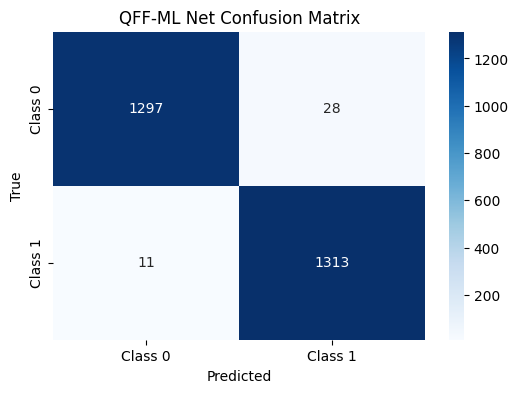

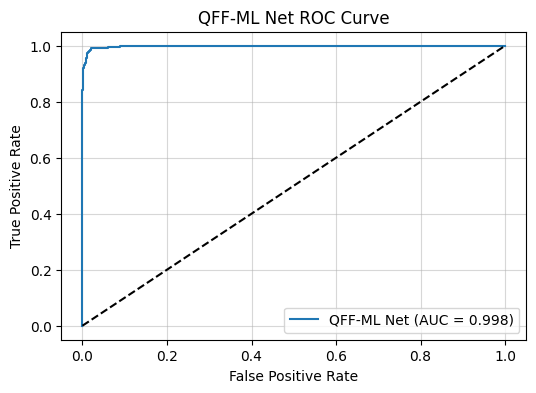


==================== Dataset: Q ====================
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning Logistic Regression...
Tuning SVC...
QFF-ML Net
Accuracy: 0.9154397885994715
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91      1325
           1       0.89      0.94      0.92      1324

    accuracy                           0.92      2649
   macro avg       0.92      0.92      0.92      2649
weighted avg       0.92      0.92      0.92      2649



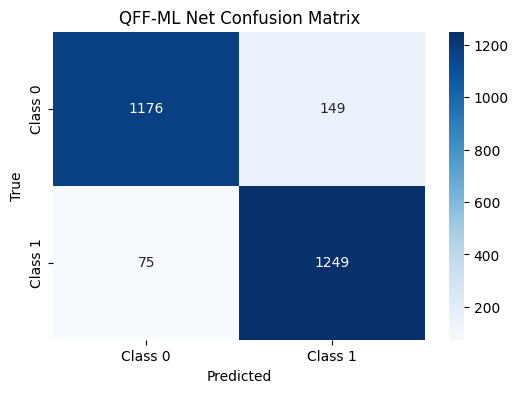

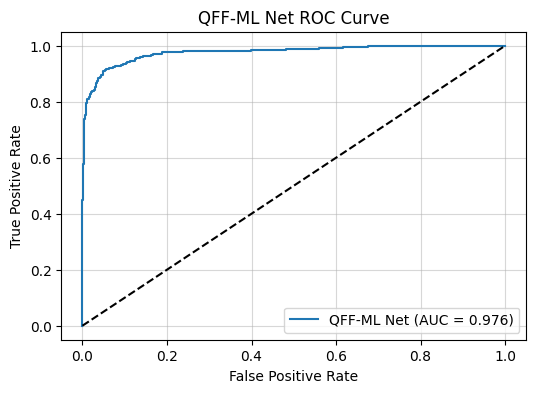


==================== Dataset: QC ====================
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning Logistic Regression...
Tuning SVC...
QFF-ML Net
Accuracy: 0.9837674594186485
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      1325
           1       0.98      0.99      0.98      1324

    accuracy                           0.98      2649
   macro avg       0.98      0.98      0.98      2649
weighted avg       0.98      0.98      0.98      2649



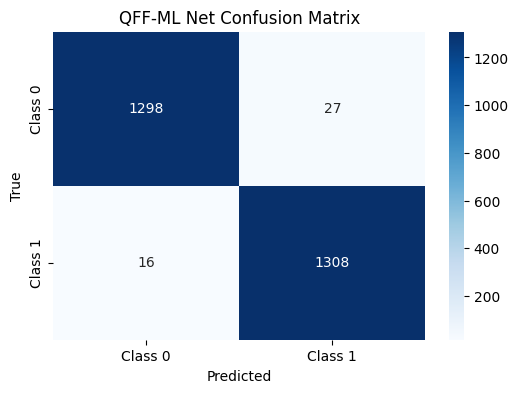

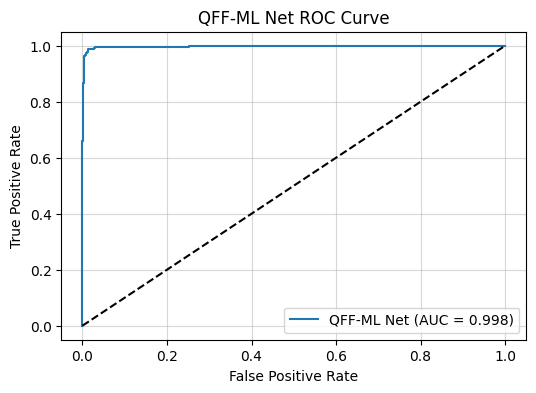

In [43]:
datasets = {
    "C": C_clean,
    "Q": Q_clean,
    "QC": QC_clean
}

for name, df in datasets.items():
    print(f"\n==================== Dataset: {name} ====================")
    
    X = df.drop('label', axis=1)
    y = df['label']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    qff_ml_net = QFFMLNet(random_state=42)
    qff_ml_net.tune_models(X_train, y_train)
    qff_ml_net.train_ensemble(X_train, y_train)
    qff_ml_net.evaluate(X_test, y_test)


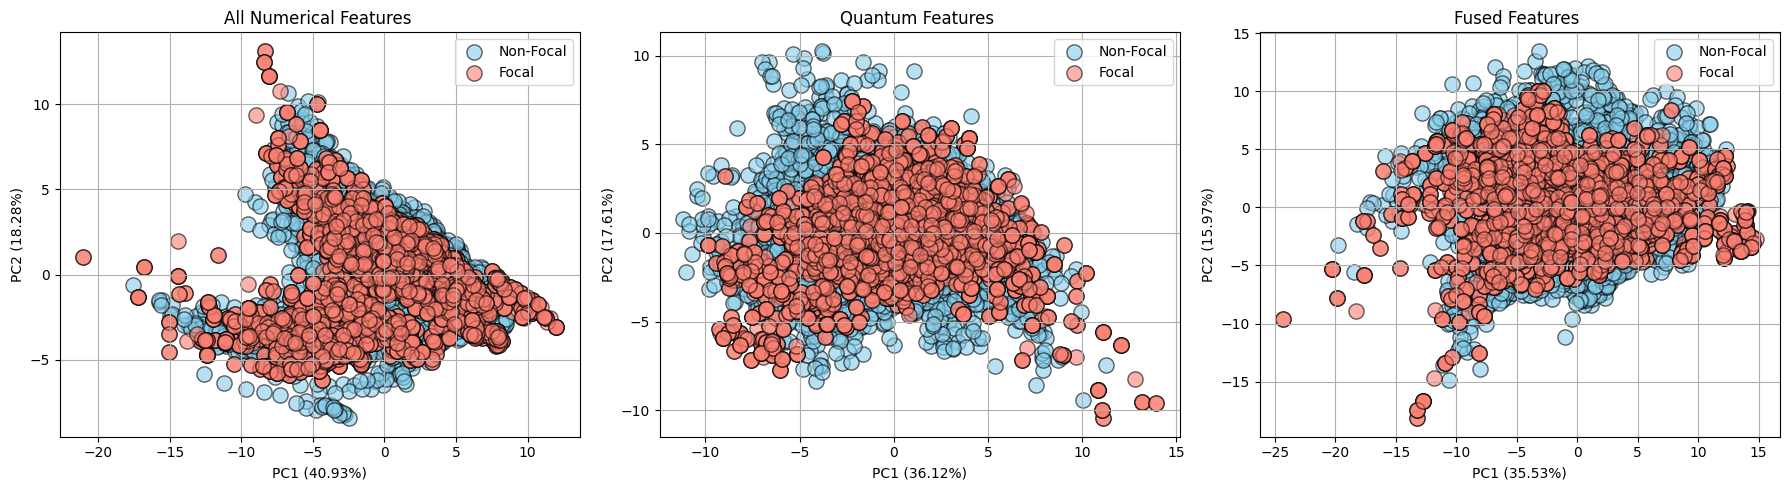

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Clean datasets
datasets = {
    "All Numerical Features ": "C_clean.csv",
    "Quantum Features ": "Q_clean.csv",
    "Fused Features ": "QC_clean.csv"
}

colors = {0: 'skyblue', 1: 'salmon'}
labels_dict = {0: 'Non-Focal', 1: 'Focal'}

plt.figure(figsize=(18, 5))

for i, (name, path) in enumerate(datasets.items(), 1):
    df = pd.read_csv(path)
    
    X = df.drop('label', axis=1)
    y = df['label']
    
    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)
    
    # PCA to 2D
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca['label'] = y.values
    
    # Plot
    plt.subplot(1, 3, i)
    for label in sorted(df_pca['label'].unique()):
        subset = df_pca[df_pca['label'] == label]
        plt.scatter(
            subset['PC1'], subset['PC2'],
            c=colors[label],
            label=labels_dict[label],
            alpha=0.6,
            edgecolors='k',
            s=120
        )
    
    plt.title(name)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()
